
# Overseas Student Enrollment in Taiwan: Data Wrangling & Visualization


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fuzzywuzzy import process

In [22]:
colTranslation = {
    '學年度': 'Year',
    '洲別': 'Continent',
    '國別': 'Country',
    '學位生_正式修讀學位外國生[人]': 'International (Degree)',
    '學位生_僑生(含港澳)[人]': 'Overseas Chinese (Degree)',
    '學位生_正式修讀學位陸生[人]': 'Mainland (Degree)',
    '非學位生_外國交換生[人]': 'Exchange (Non-degree)',
    '非學位生_外國短期研習及個人選讀[人]': 'Short-term (Non-degree)',
    '非學位生_大專附設華語文中心學生[人]': 'Mandarin training (Non-degree)',
    '非學位生_大陸研修生[人]': 'Mainland (Non-degree)'
}

continentTranslation = {
    '亞洲': 'Asia', 
    '大洋洲': 'Oceania', 
    '歐洲': 'Europe',
	'美洲': 'America',
    '非洲': 'Africa'
}

file113 = '113_ab112_C.csv'
file112 = '112_ab112_C.csv'
file103To111 = '103-111_ab111_C.csv'
fileCountryTranslation = 'countryTranslation.csv'
files = [file113, file112, file103To111]

In [23]:
def fuzzyMatch(chineseName, dict):
    """
    args:
        chineseName (str)
        dict (dict): chinese-english dictionary
    return:
        englishName (str)
    """
    manualFixes = {'大陸地區': 'China', '南韓': 'South Korea'}
    if chineseName in manualFixes:
        return manualFixes[chineseName]
    else:
        matchedName, score = process.extractOne(chineseName, dict.keys())
        return dict[matchedName]

def prepareData(files):
    """
    args:
        files (list of str)
    return:
        concat (df) 
    """
    countryTranslation = dict(pd.read_csv(fileCountryTranslation).values)
    def prepareSingleData(file):
        df = (
            pd.read_csv(file) # read
            .rename(columns=colTranslation) # Translate col
            .assign(Others = lambda df: df.drop(columns=list(colTranslation.values())).sum(axis=1)) # Total count of uncommon programs
            .pipe(lambda df: df[list(colTranslation.values())+['Others']]) # Drop uncommon programs
            .assign(Total = lambda df: df[df.columns.difference(['Year', 'Continent', 'Country'])].sum(axis=1)) # Total count of all programs           
            .assign(Continent=lambda df: df['Continent'].map(continentTranslation)) # Translate continent
            .assign(Country=lambda df: df['Country'].apply(lambda x: fuzzyMatch(x, countryTranslation))) # Translate country
        )
        return df
    return pd.concat([prepareSingleData(file) for file in files], ignore_index=True).sort_values(['Year', 'Total'], ascending=[False, False]) # Concat dataframes

def plotTop10(df):
    top10 = df.groupby('Country')['Total'].mean().nlargest(10)
    dfTop10 = df[df['Country'].isin(top10.index)]

    plt.figure(figsize=(16,8))
    sns.heatmap(
        dfTop10.pivot_table(index='Country', columns='Year', values='Total'),
        annot=True, fmt='g', cmap='Blues',
    )
    plt.title('Top 10 Countries with the Highest Average Numbers of Students in Taiwan from the Year 103 to 113', fontsize=18, fontweight='bold')
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    g = sns.FacetGrid(
        dfTop10.melt(
            id_vars=['Year', 'Country'], var_name='Student Type', value_name='Number of Students',
            value_vars=dfTop10.columns.difference(['Year', 'Continent', 'Country', 'Total'])),
        col='Student Type', col_wrap=4, sharey=False, aspect=1.25)
    g.map_dataframe(func=sns.lineplot, x='Year', y='Number of Students', hue='Country')
    g.add_legend(ncols=5, bbox_to_anchor=[0.5,1.05])
    g.figure.subplots_adjust(hspace=0.25, wspace=0.25)

    plt.show()

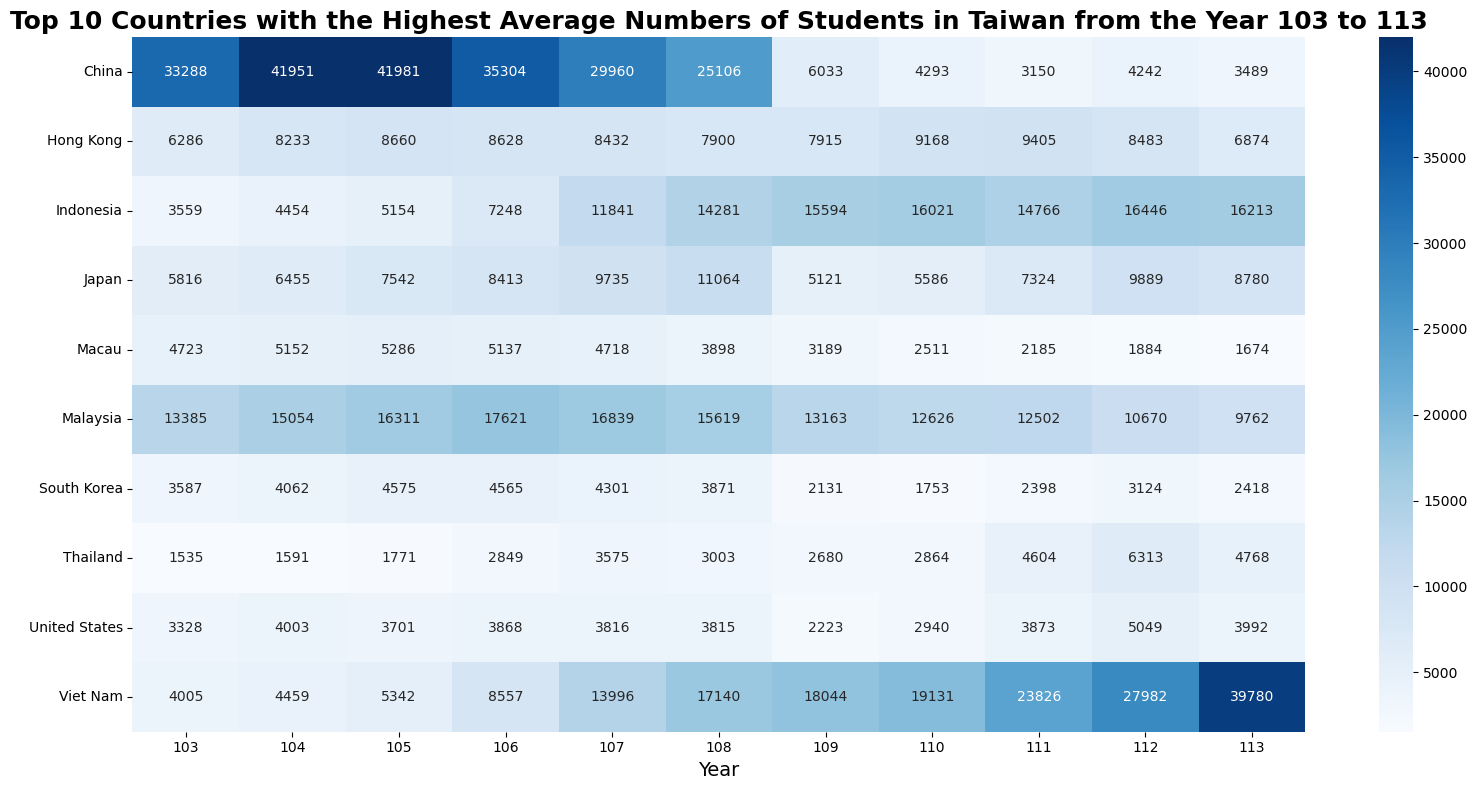

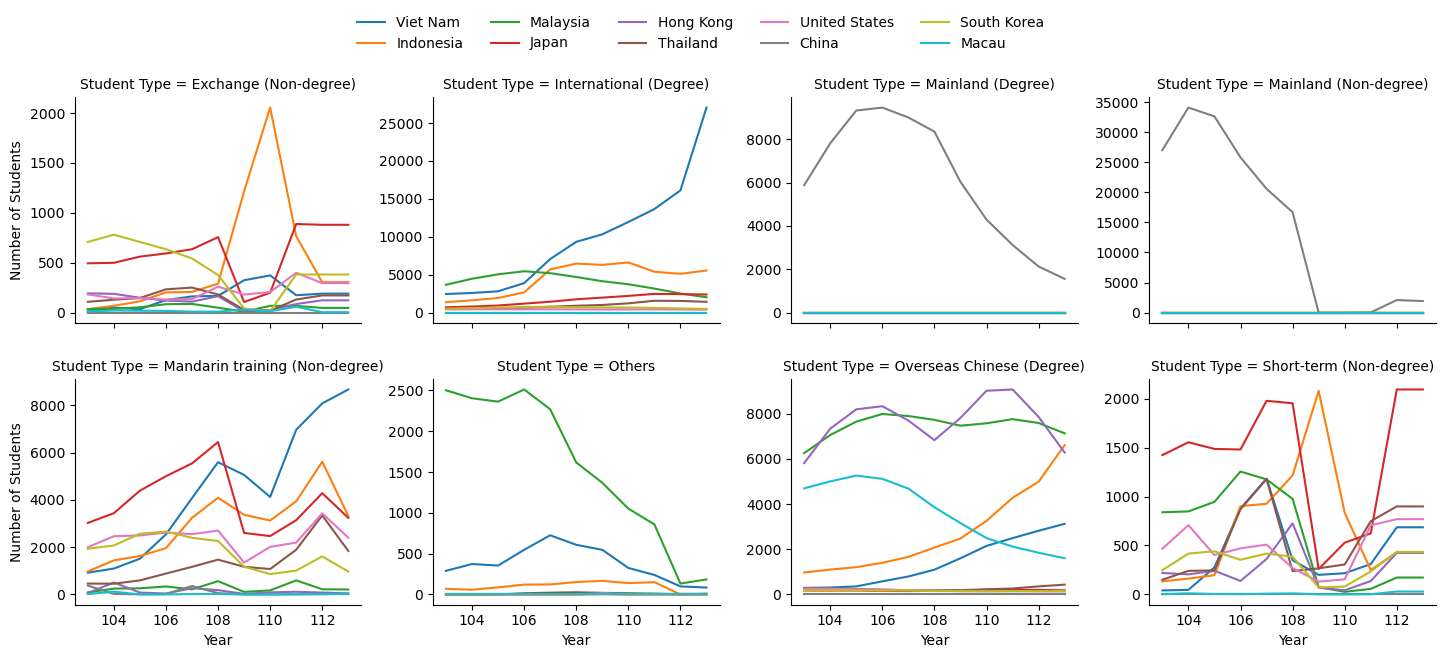

In [24]:
df = prepareData(files)
plotTop10(df)